In [1]:
import torch
import importlib.util

print("torch:", torch.__version__)
print("cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))
print("capability:", torch.cuda.get_device_capability(0))
print("vllm installed:", importlib.util.find_spec("vllm") is not None)

torch: 2.8.0+cu128
cuda: 12.8
cuda available: True
gpu: NVIDIA A100-SXM4-80GB
capability: (8, 0)
vllm installed: False


In [14]:
!pip install --no-cache-dir "vllm==0.11.0"
!pip install --no-cache-dir "qwen-vl-utils==0.0.14"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 244.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 565.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 319.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 422.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 358.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 273.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 578.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.4/819.4 kB 563.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 344.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 684.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 325.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 257.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 609.1 MB

In [15]:
import os

torch.backends.cudnn.enabled = False
os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "0"
os.environ["OMP_NUM_THREADS"] = "1"

In [16]:
import io
import json
from collections import defaultdict

from PIL import Image
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

from IPython.display import display

from transformers import AutoProcessor
from vllm import LLM, SamplingParams
from qwen_vl_utils import process_vision_info

INFO 07-13 12:07:56 [__init__.py:216] Automatically detected platform cuda.


In [17]:
# 시스템(assistant)에게 주어진 역할
system_message = "당신은 이미지와 제품명(name)으로부터 패션/스타일 정보를 추론하는 분류 모델입니다."

# 실제로 사용자 입력 -> 모델이 답해야 하는 프롬프트
prompt = """입력 정보:
- name: {name}
- image: [image]

위 정보를 바탕으로, 아래 7가지 key에 대한 값을 JSON 형태로 추론해 주세요:
1) gender
2) masterCategory
3) subCategory
4) season
5) usage
6) baseColour
7) articleType

출력 시 **아래 JSON 예시 형태**를 반드시 지키세요:
{{
  "gender": "예시값",
  "masterCategory": "예시값",
  "subCategory": "예시값",
  "season": "예시값",
  "usage": "예시값",
  "baseColour": "예시값",
  "articleType": "예시값"
}}

# 예시
{{
  "gender": "Men",
  "masterCategory": "Accessories",
  "subCategory": "Eyewear",
  "season": "Winter",
  "usage": "Casual",
  "baseColour": "Blue",
  "articleType": "Sunglasses"
}}

# 주의
- 7개 항목 이외의 정보(텍스트, 문장 등)는 절대 포함하지 마세요.
"""

In [18]:
def combine_cols_to_label(example):
    label_dict = {
        "gender": example["gender"],
        "masterCategory": example["masterCategory"],
        "subCategory": example["subCategory"],
        "season": example["season"],
        "usage": example["usage"],
        "baseColour": example["baseColour"],
        "articleType": example["articleType"],
    }

    example["label"] = json.dumps(label_dict, ensure_ascii=False)
    return example


def format_data(sample):
    # Image.Image를 PngImageFile로 변환
    buffer = io.BytesIO()
    sample["image"].save(buffer, format="PNG")
    buffer.seek(0)
    image = Image.open(buffer).convert("RGB")

    return {
        "messages": [
            {
                "role": "system",
                "content": [
                    {"type": "text", "text": system_message},
                ],
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt.format(name=sample["productDisplayName"])},
                    {"type": "image", "image": image},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": sample["label"]},
                ],
            },
        ],
    }

In [19]:
dataset = load_dataset("ashraq/fashion-product-images-small", split="train")

dataset_add_label = dataset.map(combine_cols_to_label)
dataset_add_label = dataset_add_label.shuffle(seed=4242)

formatted_dataset = [format_data(row) for row in dataset_add_label]

# test_size=0.9로 설정하여 전체 데이터의 90%를 테스트 세트로 분리
train_dataset, test_dataset = train_test_split(
    formatted_dataset,
    test_size=0.9,
    random_state=42,
)

print("학습 데이터의 개수:", len(train_dataset))
print("테스트 데이터의 개수:", len(test_dataset))

학습 데이터의 개수: 4407
테스트 데이터의 개수: 39665


In [20]:
MODEL_PATH = "iamjoon/Qwen3-VL-4B-Instruct-fashion-product-images-small-checkpoint-552"

processor = AutoProcessor.from_pretrained(
    MODEL_PATH,
    trust_remote_code=True,
)

llm = LLM(
    model=MODEL_PATH,
    dtype="bfloat16",
    max_model_len=4096,
    gpu_memory_utilization=0.50,
    limit_mm_per_prompt={"image": 1, "video": 0},
    skip_mm_profiling=True,
    enforce_eager=True,
)


preprocessor_config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model-00005-of-00005.safetensors:   0%|          | 0.00/978M [00:00<?, ?B/s]

INFO 07-13 12:09:54 [weight_utils.py:413] Time spent downloading weights for iamjoon/Qwen3-VL-4B-Instruct-fashion-product-images-small-checkpoint-552: 29.611911 seconds


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading safetensors checkpoint shards:   0% Completed | 0/5 [00:00<?, ?it/s]


INFO 07-13 12:09:56 [default_loader.py:267] Loading weights took 1.77 seconds
INFO 07-13 12:09:57 [gpu_model_runner.py:2653] Model loading took 8.6789 GiB and 31.860273 seconds
INFO 07-13 12:09:57 [gpu_model_runner.py:3329] Skipping memory profiling for multimodal encoder and encoder cache.
INFO 07-13 12:10:00 [gpu_worker.py:298] Available KV cache memory: 29.48 GiB
INFO 07-13 12:10:00 [kv_cache_utils.py:1087] GPU KV cache size: 214,672 tokens
INFO 07-13 12:10:00 [kv_cache_utils.py:1091] Maximum concurrency for 4,096 tokens per request: 52.41x
WARNING 07-13 12:10:00 [cudagraph_dispatcher.py:106] cudagraph dispatching keys are not initialized. No cudagraph will be used.
INFO 07-13 12:10:01 [core.py:210] init engine (profile, create kv cache, warmup model) took 3.72 seconds
INFO 07-13 12:10:01 [llm.py:306] Supported_tasks: ('generate',)


In [21]:
sampling_params = SamplingParams(
    temperature=0.1,
    top_p=0.001,
    repetition_penalty=1.05,
    max_tokens=256,
    stop_token_ids=[],
)

In [22]:
def split_input_and_label(prompt_text):
    assistant_marker = "<|im_start|>assistant"

    if assistant_marker not in prompt_text:
        raise ValueError("prompt_text 안에 <|im_start|>assistant 가 없습니다.")

    input_part, label_part = prompt_text.rsplit(assistant_marker, 1)
    input_part = input_part + assistant_marker + "\n"

    return input_part, label_part


def clean_label_text(label_text):
    label_text = label_text.strip()

    if label_text.endswith("<|im_end|>"):
        label_text = label_text[:-len("<|im_end|>")]

    return label_text.strip()


def build_mm_data(messages):
    result = process_vision_info(
        messages,
        image_patch_size=processor.image_processor.patch_size,
        return_video_kwargs=True,
        return_video_metadata=True,
    )

    if len(result) == 3:
        image_inputs, video_inputs, video_kwargs = result
    elif len(result) == 2:
        image_inputs, video_inputs = result
        video_kwargs = {}
    else:
        raise ValueError(f"process_vision_info 반환값 개수가 예상과 다릅니다: {len(result)}")

    mm_data = {}

    if image_inputs is not None and len(image_inputs) > 0:
        mm_data["image"] = image_inputs

    if video_inputs is not None and len(video_inputs) > 0:
        mm_data["video"] = video_inputs

    if video_kwargs is None:
        video_kwargs = {}

    return mm_data, image_inputs, video_inputs, video_kwargs

In [23]:
test_sample = test_dataset[32]["messages"]

test_sample_prompt = processor.apply_chat_template(
    test_sample,
    tokenize=False,
    add_generation_prompt=False,
)

test_sample_input, test_sample_label = split_input_and_label(test_sample_prompt)

print(test_sample_input)

<|im_start|>system
당신은 이미지와 제품명(name)으로부터 패션/스타일 정보를 추론하는 분류 모델입니다.<|im_end|>
<|im_start|>user
입력 정보:
- name: Colorbar Exclusive Nail Lacquer 19
- image: [image]

위 정보를 바탕으로, 아래 7가지 key에 대한 값을 JSON 형태로 추론해 주세요:
1) gender
2) masterCategory
3) subCategory
4) season
5) usage
6) baseColour
7) articleType

출력 시 **아래 JSON 예시 형태**를 반드시 지키세요:
{
  "gender": "예시값",
  "masterCategory": "예시값",
  "subCategory": "예시값",
  "season": "예시값",
  "usage": "예시값",
  "baseColour": "예시값",
  "articleType": "예시값"
}

# 예시
{
  "gender": "Men",
  "masterCategory": "Accessories",
  "subCategory": "Eyewear",
  "season": "Winter",
  "usage": "Casual",
  "baseColour": "Blue",
  "articleType": "Sunglasses"
}

# 주의
- 7개 항목 이외의 정보(텍스트, 문장 등)는 절대 포함하지 마세요.
<|vision_start|><|image_pad|><|vision_end|><|im_end|>
<|im_start|>assistant



In [24]:
print(test_sample_label)


{"gender": "Women", "masterCategory": "Personal Care", "subCategory": "Nails", "season": "Spring", "usage": "Casual", "baseColour": "Blue", "articleType": "Nail Polish"}<|im_end|>



이미지 입력:
[<PIL.Image.Image image mode=RGB size=64x64 at 0x719D5D6BF770>]


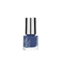

비디오 입력:
None


In [25]:
test_sample_mm_data, test_sample_image_inputs, test_sample_video_inputs, test_sample_video_kwargs = build_mm_data(test_sample)

print("이미지 입력:")
print(test_sample_image_inputs)

if test_sample_image_inputs is not None and len(test_sample_image_inputs) > 0:
    display(test_sample_image_inputs[0])

print("비디오 입력:")
print(test_sample_video_inputs)

In [26]:
llm_inputs = {
    "prompt": test_sample_input,
    "multi_modal_data": test_sample_mm_data,
}

if test_sample_video_kwargs:
    llm_inputs["mm_processor_kwargs"] = test_sample_video_kwargs

outputs = llm.generate(
    [llm_inputs],
    sampling_params=sampling_params,
)

generated_text = outputs[0].outputs[0].text

print("모델의 예측:")
print(generated_text.strip())

print("레이블:")
print(clean_label_text(test_sample_label))

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

모델의 예측:
{"gender": "Women", "masterCategory": "Personal Care", "subCategory": "Nails", "season": "Spring", "usage": "Casual", "baseColour": "Blue", "articleType": "Nail Polish"}
레이블:
{"gender": "Women", "masterCategory": "Personal Care", "subCategory": "Nails", "season": "Spring", "usage": "Casual", "baseColour": "Blue", "articleType": "Nail Polish"}


In [27]:
# 상위 50개 테스트 데이터 추출
test_samples = test_dataset[:50]

# 배치 인퍼런스를 위한 입력 데이터 준비
batch_inputs = []
batch_labels = []
batch_sample_indices = []
skipped_video_count = 0
skipped_empty_mm_count = 0

for sample_idx, sample in enumerate(test_samples):
    messages = sample["messages"]

    # 프롬프트 생성
    prompt_text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    # 입력과 레이블 분리
    input_part, label_part = split_input_and_label(prompt_text)

    # 이미지/비디오 데이터 처리
    mm_data, image_inputs, video_inputs, video_kwargs = build_mm_data(messages)

    # 현재 llm 설정이 limit_mm_per_prompt={"image": 1, "video": 0} 이므로 비디오 샘플은 제외
    if video_inputs is not None and len(video_inputs) > 0:
        print(f"샘플 {sample_idx + 1}: video 입력이 있어서 건너뜀")
        skipped_video_count += 1
        continue

    # 이미지 입력이 없는 샘플도 제외
    if image_inputs is None or len(image_inputs) == 0:
        print(f"샘플 {sample_idx + 1}: image 입력이 없어서 건너뜀")
        skipped_empty_mm_count += 1
        continue

    # LLM 입력 데이터 구성
    llm_input = {
        "prompt": input_part,
        "multi_modal_data": mm_data,
    }

    # video가 없으면 보통 비어 있지만, 반환값이 있을 경우만 추가
    if video_kwargs:
        llm_input["mm_processor_kwargs"] = video_kwargs

    batch_inputs.append(llm_input)
    batch_labels.append(label_part)
    batch_sample_indices.append(sample_idx)

print("준비된 샘플 수:", len(batch_inputs))
print("건너뛴 video 샘플 수:", skipped_video_count)
print("건너뛴 image 없음 샘플 수:", skipped_empty_mm_count)

# 배치 인퍼런스 실행
print("배치 인퍼런스 시작...")

outputs = []
batch_size = 4

for start_idx in range(0, len(batch_inputs), batch_size):
    end_idx = min(start_idx + batch_size, len(batch_inputs))
    current_inputs = batch_inputs[start_idx:end_idx]

    print(f"{start_idx + 1} ~ {end_idx} 처리 중...")

    current_outputs = llm.generate(
        current_inputs,
        sampling_params=sampling_params,
    )

    outputs.extend(current_outputs)

# 결과 출력
print("\n=== 배치 인퍼런스 결과 ===")

for i, output in enumerate(outputs):
    generated_text = output.outputs[0].text
    original_sample_idx = batch_sample_indices[i]

    print(f"\n--- 샘플 {original_sample_idx + 1} ---")
    print(f"모델의 예측: {generated_text.strip()}")
    print(f"레이블: {clean_label_text(batch_labels[i])}")
    print("-" * 50)

준비된 샘플 수: 50
건너뛴 video 샘플 수: 0
건너뛴 image 없음 샘플 수: 0
배치 인퍼런스 시작...
1 ~ 4 처리 중...


Adding requests:   0%|          | 0/4 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/4 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

5 ~ 8 처리 중...


Adding requests:   0%|          | 0/4 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/4 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

49 ~ 50 처리 중...


Adding requests:   0%|          | 0/2 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


=== 배치 인퍼런스 결과 ===

--- 샘플 1 ---
모델의 예측: {"gender": "Women", "masterCategory": "Apparel", "subCategory": "Dress", "season": "Summer", "usage": "Casual", "baseColour": "Beige", "articleType": "Dresses"}
레이블: {"gender": "Women", "masterCategory": "Apparel", "subCategory": "Dress", "season": "Winter", "usage": "Casual", "baseColour": "Beige", "articleType": "Dresses"}
--------------------------------------------------

--- 샘플 2 ---
모델의 예측: {"gender": "Women", "masterCategory": "Accessories", "subCategory": "Bags", "season": "Summer", "usage": "Casual", "baseColour": "Copper", "articleType": "Clutches"}
레이블: {"gender": "Women", "masterCategory": "Accessories", "subCategory": "Bags", "season": "Summer", "usage": "Casual", "baseColour": "Copper", "articleType": "Clutches"}
--------------------------------------------------

--- 샘플 3 ---
모델의 예측: {"gender": "Men", "masterCategory": "Apparel", "subCategory": "Topwear", "season": "Summer", "usage": "Casual", "baseColour": "Blue", "articleType":

In [28]:
def extract_json_from_text(text):
    text = text.strip()

    if text.endswith("<|im_end|>"):
        text = text[:-len("<|im_end|>")].strip()

    start_idx = text.find("{")
    end_idx = text.rfind("}")

    if start_idx == -1 or end_idx == -1 or end_idx <= start_idx:
        raise ValueError("JSON 객체를 찾을 수 없습니다.")

    json_text = text[start_idx:end_idx + 1]

    return json.loads(json_text)


def calculate_f1_scores(outputs, batch_labels):
    """각 key별로 F1 score를 계산하는 함수"""

    predictions_by_key = defaultdict(list)
    labels_by_key = defaultdict(list)

    parse_fail_count = 0
    missing_key_count = 0

    for i, output in enumerate(outputs):
        # 모델 예측 결과 파싱
        try:
            pred_text = output.outputs[0].text.strip()
            pred_json = extract_json_from_text(pred_text)
        except Exception as e:
            print(f"샘플 {i + 1}: 예측 결과 JSON 파싱 실패")
            print("예측 원문:", output.outputs[0].text.strip())
            print("에러:", e)
            parse_fail_count += 1
            continue

        # 실제 레이블 파싱
        try:
            label_text = clean_label_text(batch_labels[i])
            label_json = json.loads(label_text)
        except Exception as e:
            print(f"샘플 {i + 1}: 레이블 JSON 파싱 실패")
            print("레이블 원문:", batch_labels[i])
            print("에러:", e)
            parse_fail_count += 1
            continue

        # 레이블에 있는 key를 기준으로 평가
        for key in label_json.keys():
            if key in pred_json:
                predictions_by_key[key].append(str(pred_json[key]))
                labels_by_key[key].append(str(label_json[key]))
            else:
                print(f"샘플 {i + 1}: 키 '{key}' 예측 결과에 없음")
                missing_key_count += 1

    f1_scores = {}

    for key in labels_by_key.keys():
        if len(labels_by_key[key]) > 0:
            unique_labels = list(set(labels_by_key[key] + predictions_by_key[key]))

            if len(unique_labels) == 1:
                f1_scores[key] = 1.0
            else:
                f1_scores[key] = f1_score(
                    labels_by_key[key],
                    predictions_by_key[key],
                    labels=unique_labels,
                    average="macro",
                    zero_division=0,
                )

    return f1_scores, predictions_by_key, labels_by_key, parse_fail_count, missing_key_count

In [29]:
f1_results, preds_by_key, labels_by_key, parse_fail_count, missing_key_count = calculate_f1_scores(
    outputs,
    batch_labels,
)

print("\n=== F1 Score 결과 ===")
print(f"{'Key':<15} {'F1 Score':<10} {'샘플 수':<8}")
print("-" * 35)

for key, score in f1_results.items():
    sample_count = len(labels_by_key[key])
    print(f"{key:<15} {score:.4f}     {sample_count}")

if f1_results:
    avg_f1 = sum(f1_results.values()) / len(f1_results)
    print("-" * 35)
    print(f"{'평균 F1':<15} {avg_f1:.4f}")

print("\n파싱 실패 수:", parse_fail_count)
print("누락 키 수:", missing_key_count)

print("\n=== 상세 결과 ===")
for key in f1_results.keys():
    correct = sum(1 for p, l in zip(preds_by_key[key], labels_by_key[key]) if p == l)
    total = len(labels_by_key[key])
    accuracy = correct / total if total > 0 else 0
    print(f"{key}: 정확도 {accuracy:.4f} ({correct}/{total})")


=== F1 Score 결과 ===
Key             F1 Score   샘플 수    
-----------------------------------
gender          0.7742     50
masterCategory  1.0000     50
subCategory     1.0000     50
season          0.7877     50
usage           0.8106     50
baseColour      0.9131     50
articleType     0.9870     50
-----------------------------------
평균 F1           0.8961

파싱 실패 수: 0
누락 키 수: 0

=== 상세 결과 ===
gender: 정확도 0.9600 (48/50)
masterCategory: 정확도 1.0000 (50/50)
subCategory: 정확도 1.0000 (50/50)
season: 정확도 0.7600 (38/50)
usage: 정확도 0.8600 (43/50)
baseColour: 정확도 0.9600 (48/50)
articleType: 정확도 0.9800 (49/50)
